# Training Log Parser and Visualizer

This notebook parses training logs and creates plots for each metric.

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple

# Try to use a nice style, fallback to default if not available
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('default')
        plt.rcParams['axes.grid'] = True
        plt.rcParams['grid.alpha'] = 0.3

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

In [2]:
def parse_log_file(file_path: str) -> Dict:
    """
    Parse a training log file and extract metrics.
    
    Returns a dictionary with:
    - 'config': configuration parameters
    - 'metrics': dictionary of metric_name -> list of (epoch, value) tuples
    """
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Extract configuration
    config = {}
    config_match = re.search(r'Namespace\(([^)]+)\)', content)
    if config_match:
        config_str = config_match.group(1)
        for item in config_str.split(','):
            if '=' in item:
                key, value = item.split('=', 1)
                key = key.strip()
                value = value.strip()
                # Try to convert to appropriate type
                try:
                    if '.' in value:
                        config[key] = float(value)
                    else:
                        config[key] = int(value)
                except ValueError:
                    config[key] = value
    

    metrics = defaultdict(list)
    
    for line in content.split('\n'):
        match = re.search(r'^([a-z/][^@]+?)\s+@\s+write\s+(\d+)\s+=\s+([-\d.]+)', line)
        if match:
            metric_name = match.group(1).strip()
            epoch = int(match.group(2))
            value = float(match.group(3))
            metrics[metric_name].append((epoch, value))
        
        time_match = re.search(r'Epoch\s+(\d+)/\d+\s+-\s+Time:\s+([\d.]+)s', line)
        if time_match:
            epoch = int(time_match.group(1))
            time_seconds = float(time_match.group(2))
            metrics['time_per_epoch'].append((epoch, time_seconds))
    
    for metric_name in metrics:
        metrics[metric_name].sort(key=lambda x: x[0])
    
    return {
        'config': config,
        'metrics': dict(metrics),
        'file_name': Path(file_path).stem
    }

In [3]:
# Output folder for saved plots (meaningful filenames per metric)
LOG_PLOTS_DIR = Path('log_plots')


def _metric_to_filename(metric_name: str) -> str:
    """Convert metric name to a safe filename (e.g. 'train/bpd' -> 'train_bpd')."""
    safe = re.sub(r'[^\w/.-]', '_', metric_name)
    safe = safe.replace('/', '_').strip('_')
    return safe or 'metric'


def plot_metrics(parsed_logs: List[Dict], metric_names: List[str] = None, save_dir: Path = None):
    """
    Plot metrics from multiple log files.
    
    Args:
        parsed_logs: List of parsed log dictionaries
        metric_names: List of metric names to plot. If None, plots all metrics.
        save_dir: Directory to save figures. If None, uses LOG_PLOTS_DIR. Created if missing.
    """
    if not parsed_logs:
        print("No logs to plot!")
        return
    
    out_dir = Path(save_dir) if save_dir is not None else LOG_PLOTS_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    
    if metric_names is None:
        all_metrics = set()
        for log in parsed_logs:
            all_metrics.update(log['metrics'].keys())
        metric_names = sorted(all_metrics)
    
    for metric_name in metric_names:
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('none')
        ax.set_facecolor('none')
        
        for log in parsed_logs:
            if metric_name in log['metrics']:
                epochs, values = zip(*log['metrics'][metric_name])
                label = log['file_name']
                if log['config']:
                    config_parts = []
                    for key in ['n_blocks', 'depth', 'z_size', 'h_size', 'free_bits', 'lr', 'iaf']:
                        if key in log['config']:
                            config_parts.append(f"{key}={log['config'][key]}")
                    if config_parts:
                        label = f"{log['file_name']} ({', '.join(config_parts[:3])})"
                
                ax.plot(epochs, values, marker='o', label=label, linewidth=2, markersize=4)
        
        ax.set_xlabel('Epoch', fontsize=16)
        ax.set_ylabel(metric_name, fontsize=16)
        ax.legend(loc='best', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=12)
        
        plt.tight_layout()
        fname = _metric_to_filename(metric_name) + '_over_training.png'
        fig.savefig(out_dir / fname, transparent=True, bbox_inches='tight', dpi=150)
        print(f"Saved: {out_dir / fname}")
        plt.show()

## Usage

1. Specify the log file paths in the cell below
2. Run all cells to generate plots

In [13]:
# Specify your log file paths here
# You can add multiple files to compare different runs
log_files = [
    "logs/strong_decoder_no_iaf_matched_to4blocks.txt",
    "logs/4_block_iaf.txt",
    "logs/shallow_decoder_no_iaf.txt"
    # 'path/to/log2.txt',
]

In [14]:
parsed_logs = []
for log_file in log_files:
    try:
        parsed = parse_log_file(log_file)
        parsed_logs.append(parsed)
        print(f"✓ Parsed {log_file}")
        print(f"  Found {len(parsed['metrics'])} metrics")
        print(f"  Config: {parsed['config']}")
    except Exception as e:
        print(f"✗ Error parsing {log_file}: {e}")

print(f"\nTotal logs parsed: {len(parsed_logs)}")

✓ Parsed logs/strong_decoder_no_iaf_matched_to4blocks.txt
  Found 11 metrics
  Config: {'n_blocks': 5, 'depth': 2, 'z_size': 32, 'h_size': 64, 'n_epochs': 50, 'batch_size': 128, 'free_bits': 0.2, 'lr': 0.002, 'iaf': 0}
✓ Parsed logs/4_block_iaf.txt
  Found 11 metrics
  Config: {'debug': 'False', 'n_blocks': 4, 'depth': 2, 'z_size': 32, 'h_size': 64, 'n_epochs': 50, 'warmup': 10, 'batch_size': 128, 'free_bits': 0.2, 'iaf': 1, 'lr': 0.002}
✓ Parsed logs/shallow_decoder_no_iaf.txt
  Found 11 metrics
  Config: {'debug': 'False', 'n_blocks': 4, 'depth': 2, 'z_size': 32, 'h_size': 64, 'n_epochs': 50, 'warmup': 10, 'batch_size': 128, 'free_bits': 0.2, 'iaf': 0, 'ar_prior': 0, 'lr': 0.002}

Total logs parsed: 3


Saved: log_plots/test_bpd_over_training.png


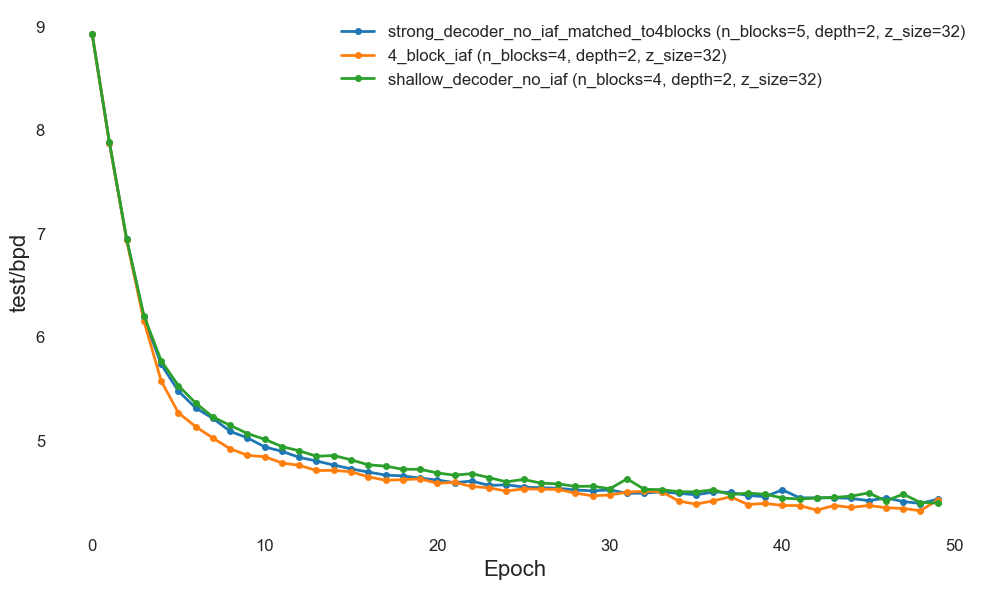

Saved: log_plots/test_elbo_over_training.png


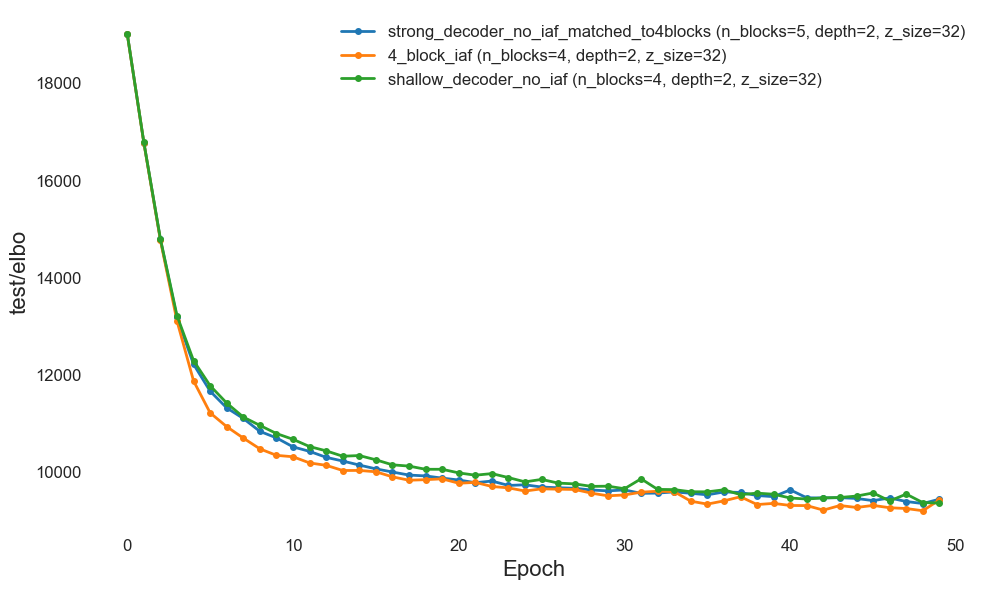

Saved: log_plots/test_kl_over_training.png


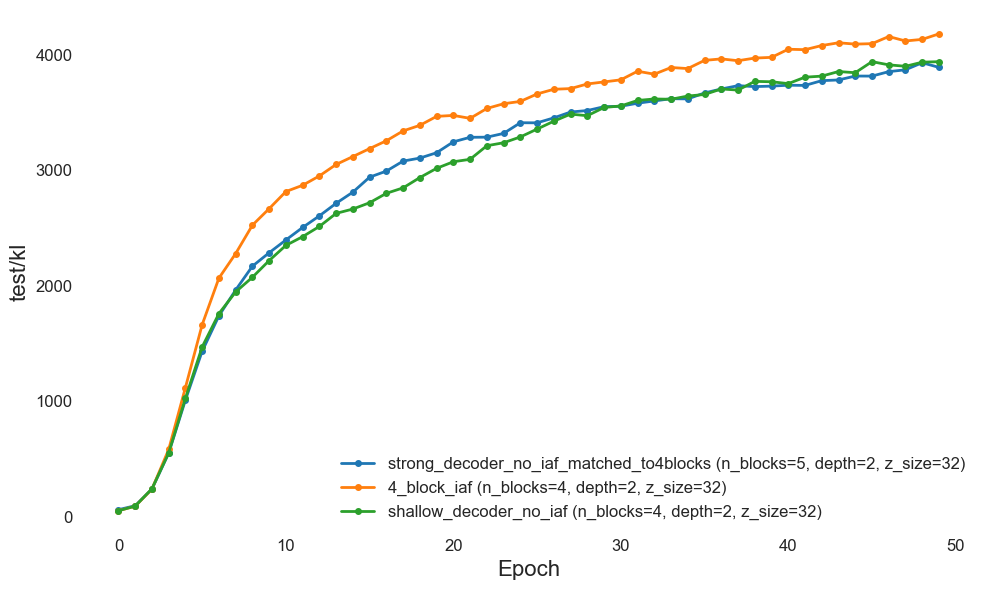

Saved: log_plots/test_kl_obj_over_training.png


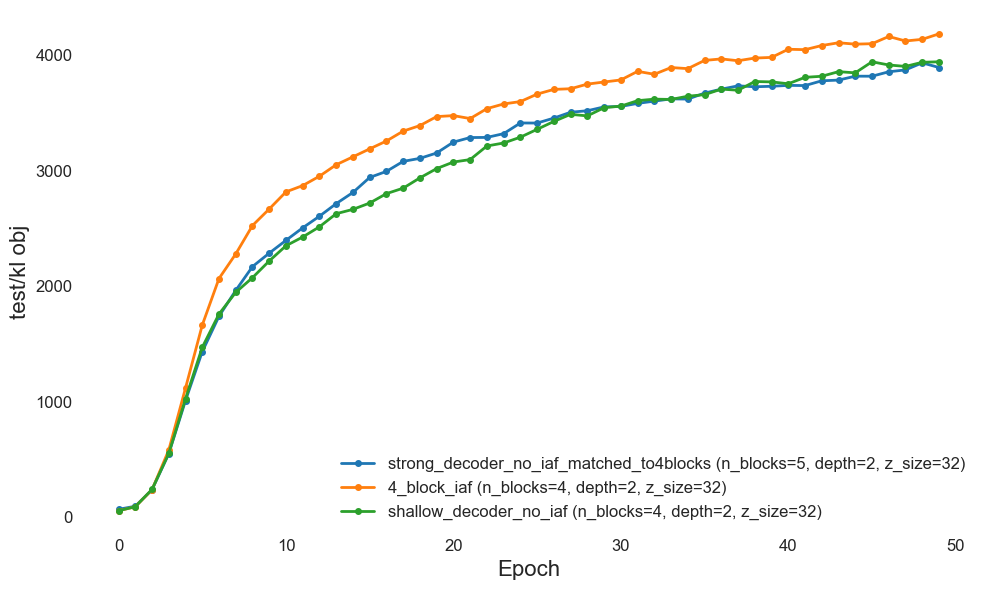

Saved: log_plots/test_log_p_x_z_over_training.png


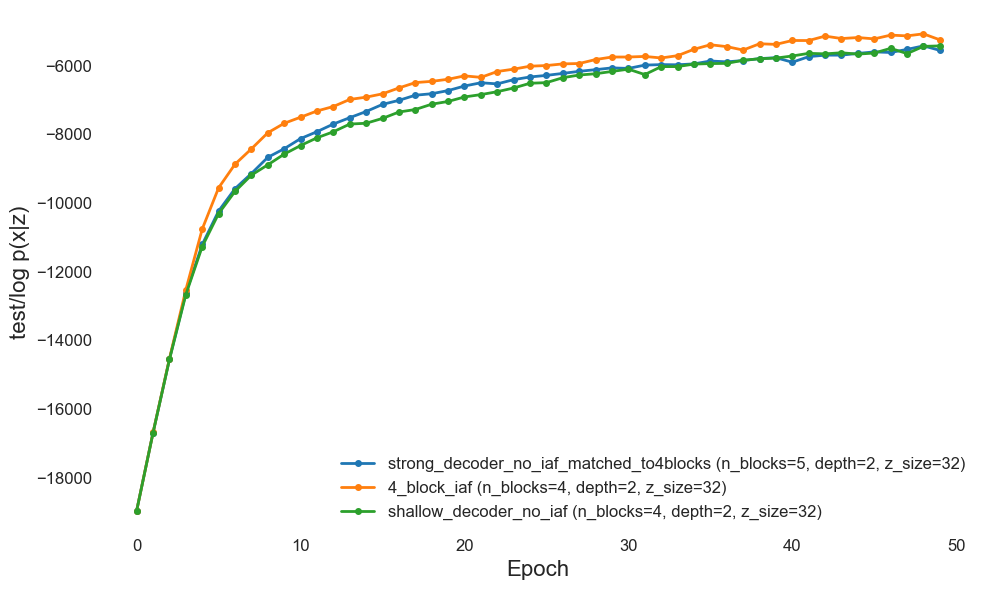

Saved: log_plots/time_per_epoch_over_training.png


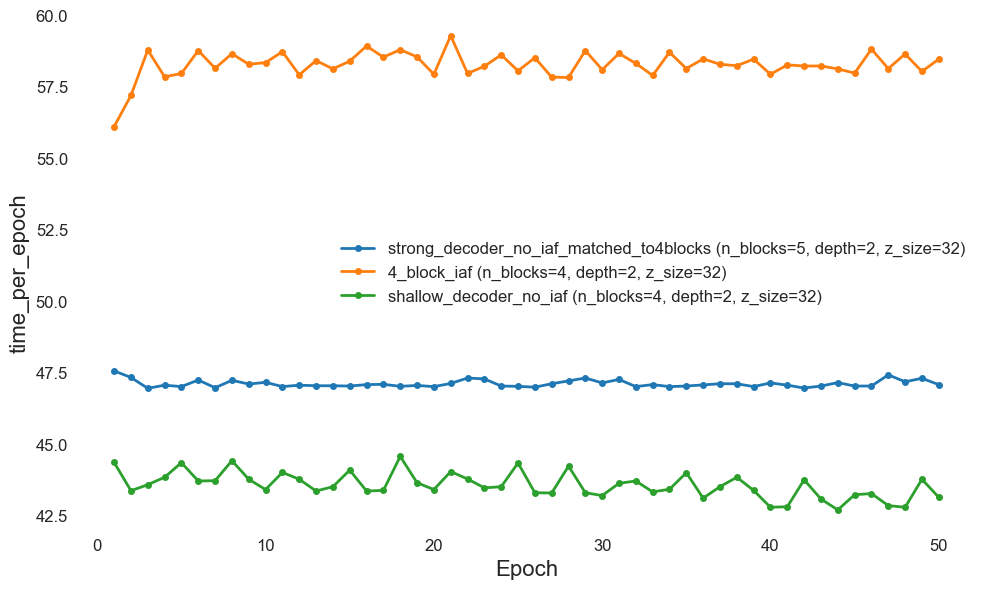

Saved: log_plots/train_bpd_over_training.png


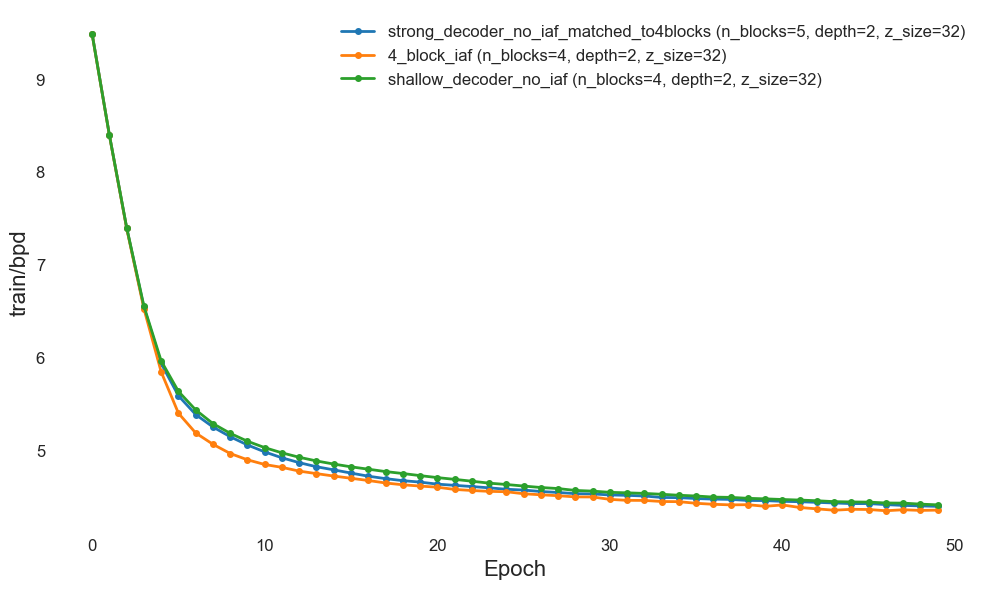

Saved: log_plots/train_elbo_over_training.png


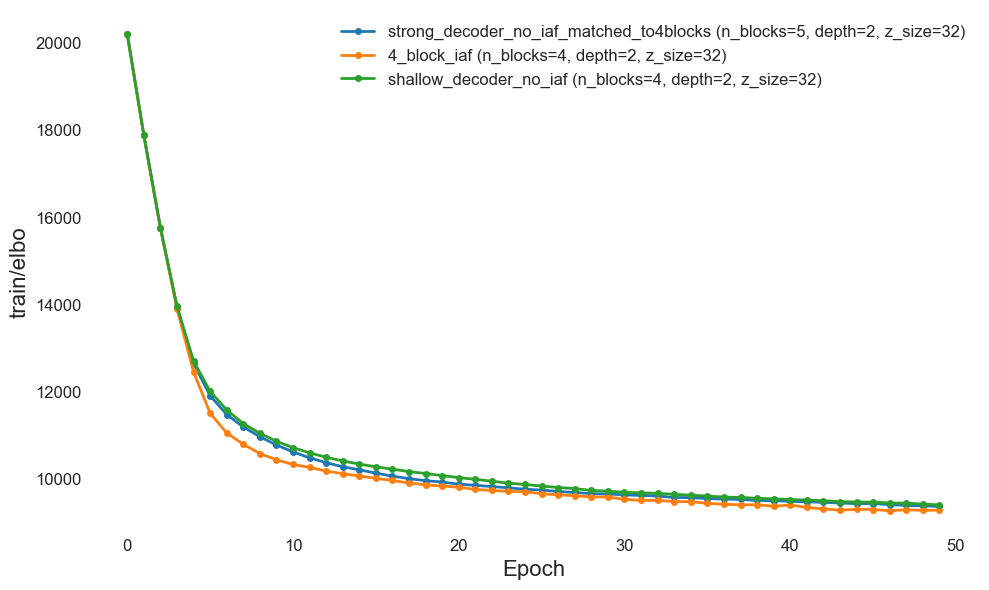

Saved: log_plots/train_kl_over_training.png


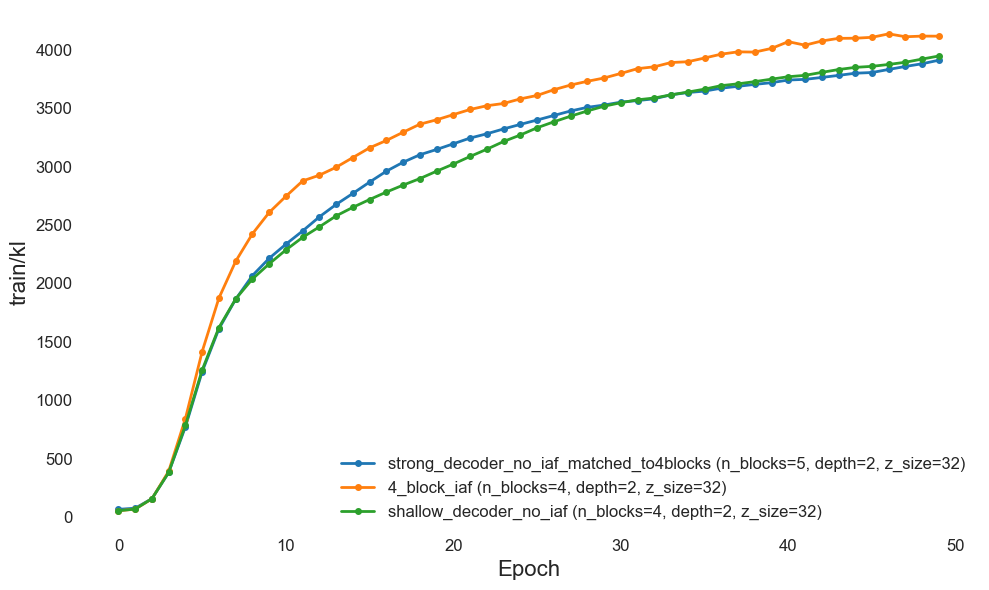

Saved: log_plots/train_kl_obj_over_training.png


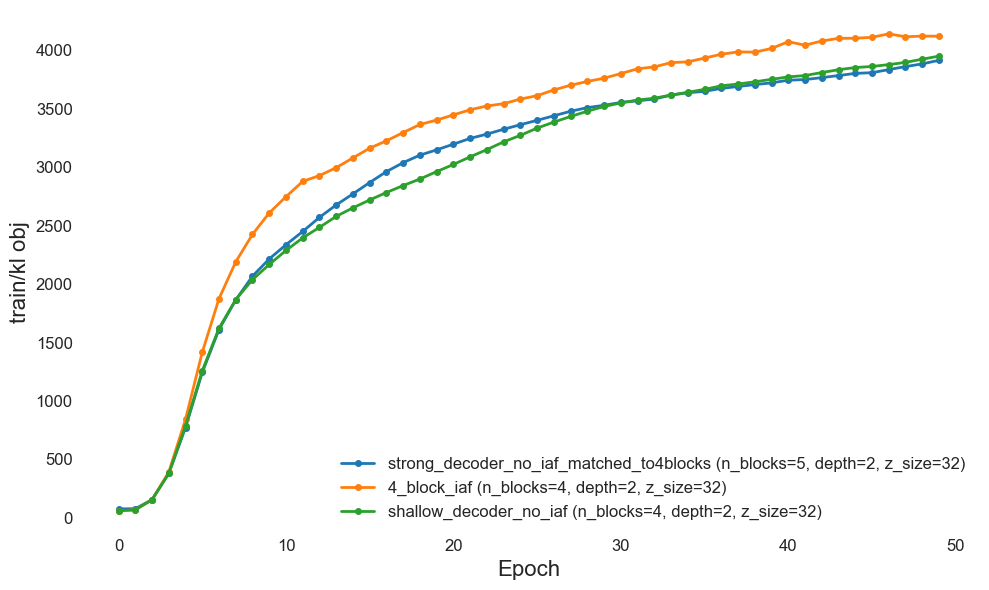

Saved: log_plots/train_log_p_x_z_over_training.png


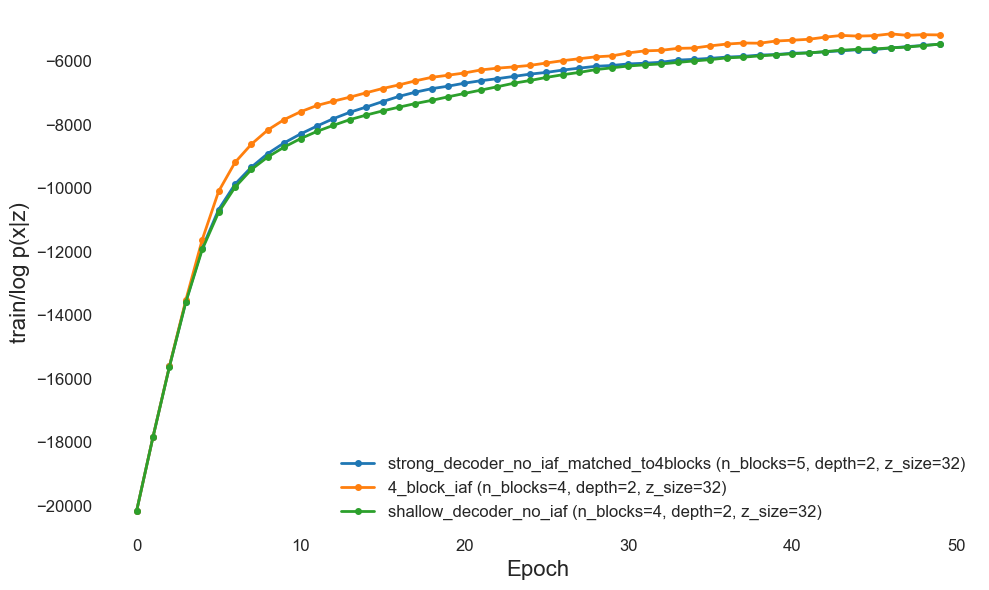

In [15]:
# Plot all metrics
if parsed_logs:
    plot_metrics(parsed_logs)
else:
    print("No logs to plot. Please specify log files in the cell above.")

✓ Parsed logs/capacity/more_blocks/iaf.txt
  Found 11 metrics
  Config: {'debug': 'False', 'n_blocks': 8, 'depth': 2, 'z_size': 32, 'h_size': 64, 'n_epochs': 50, 'warmup': 10, 'batch_size': 128, 'free_bits': 0.2, 'iaf': 1, 'ar_prior': 0, 'lr': 0.002}
✓ Parsed logs/capacity/more_blocks/non_iaf.txt
  Found 11 metrics
  Config: {'debug': 'False', 'n_blocks': 10, 'depth': 2, 'z_size': 32, 'h_size': 64, 'n_epochs': 50, 'warmup': 10, 'batch_size': 128, 'free_bits': 0.2, 'iaf': 0, 'ar_prior': 0, 'lr': 0.002}

Total logs parsed: 2
Saved: log_plots/capacity/more_blocks/test_bpd_over_training.png


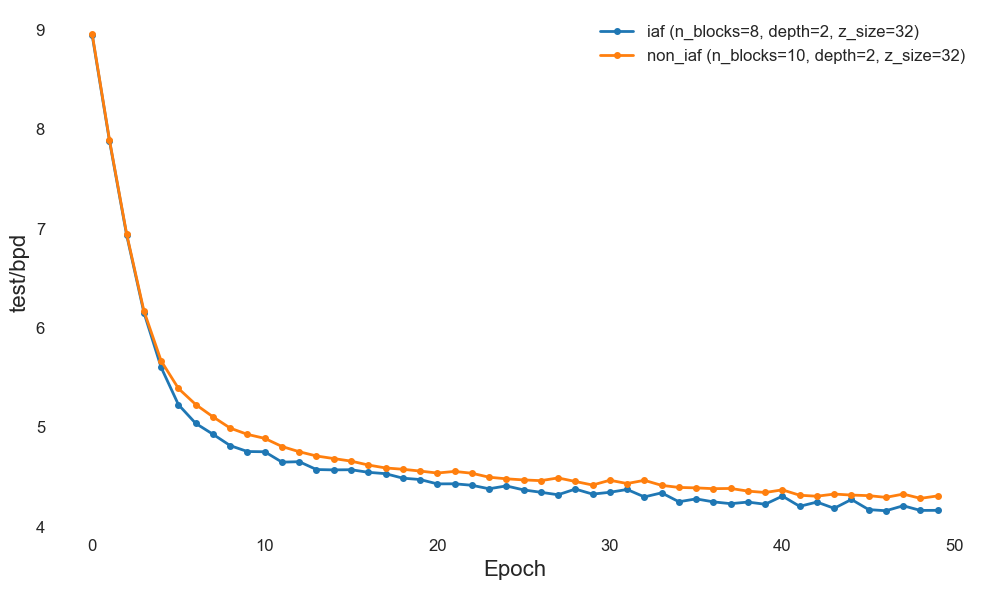

Saved: log_plots/capacity/more_blocks/test_elbo_over_training.png


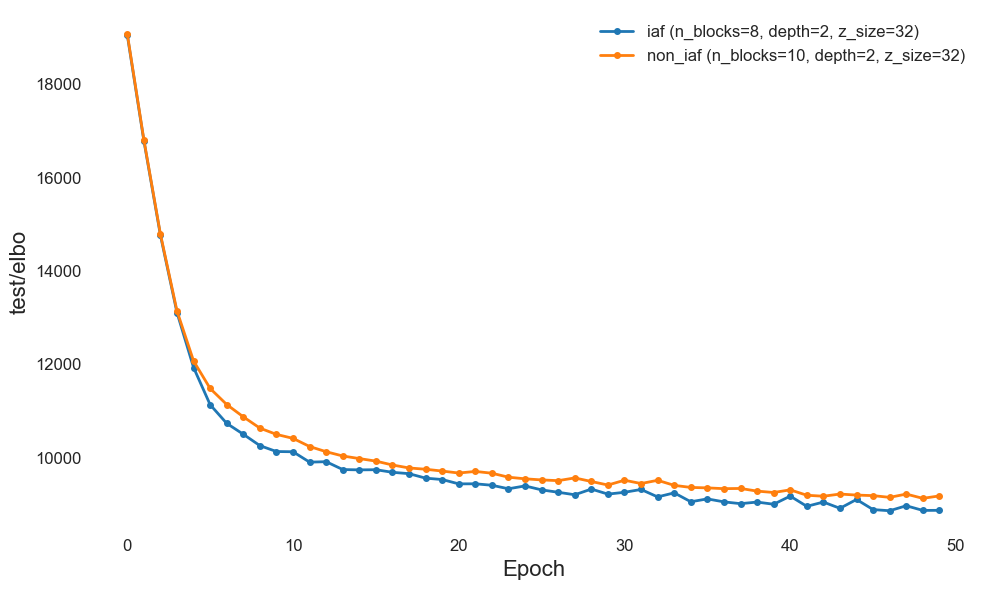

Saved: log_plots/capacity/more_blocks/test_kl_over_training.png


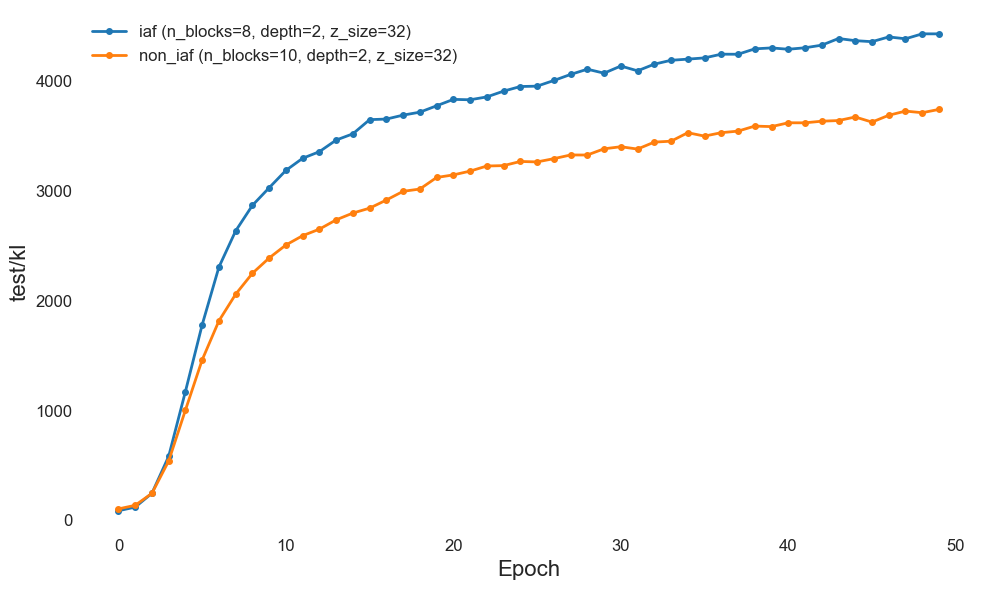

Saved: log_plots/capacity/more_blocks/test_kl_obj_over_training.png


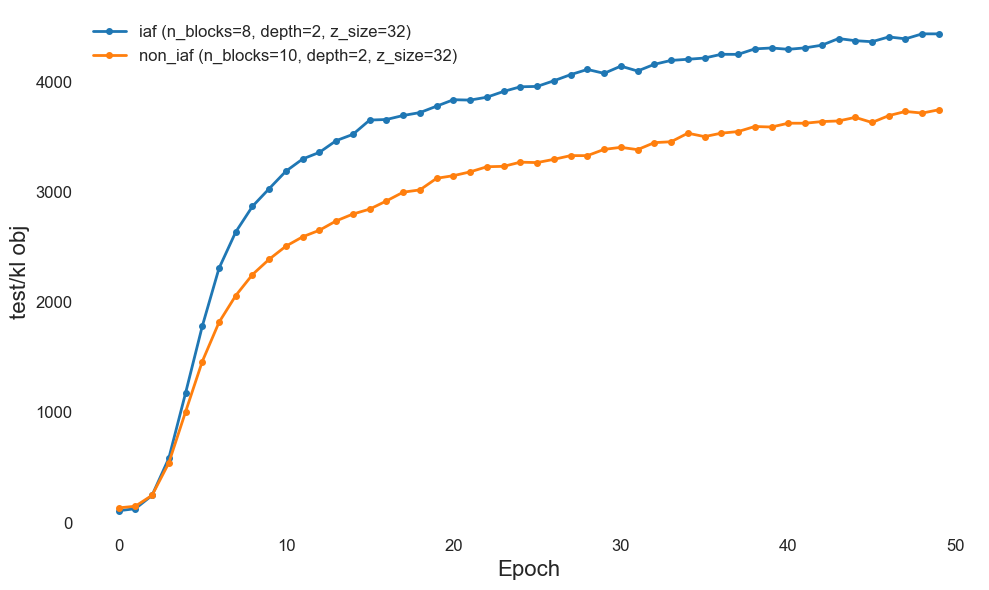

Saved: log_plots/capacity/more_blocks/test_log_p_x_z_over_training.png


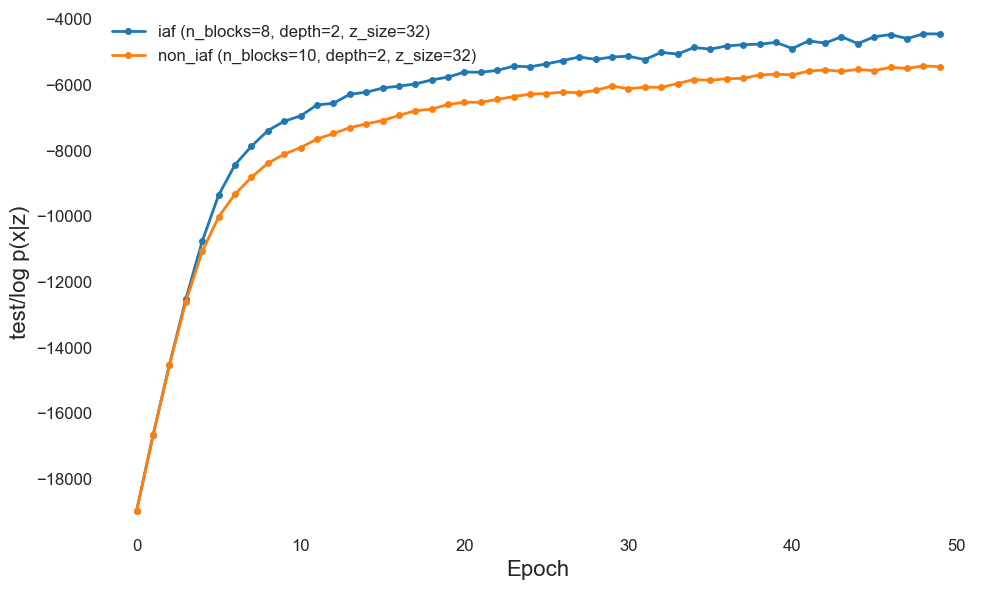

Saved: log_plots/capacity/more_blocks/time_per_epoch_over_training.png


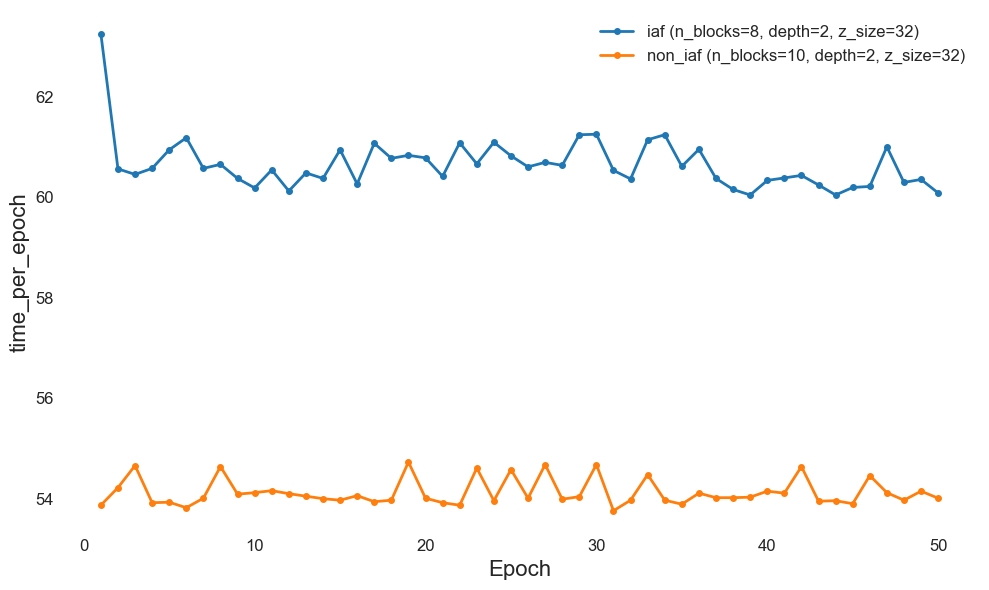

Saved: log_plots/capacity/more_blocks/train_bpd_over_training.png


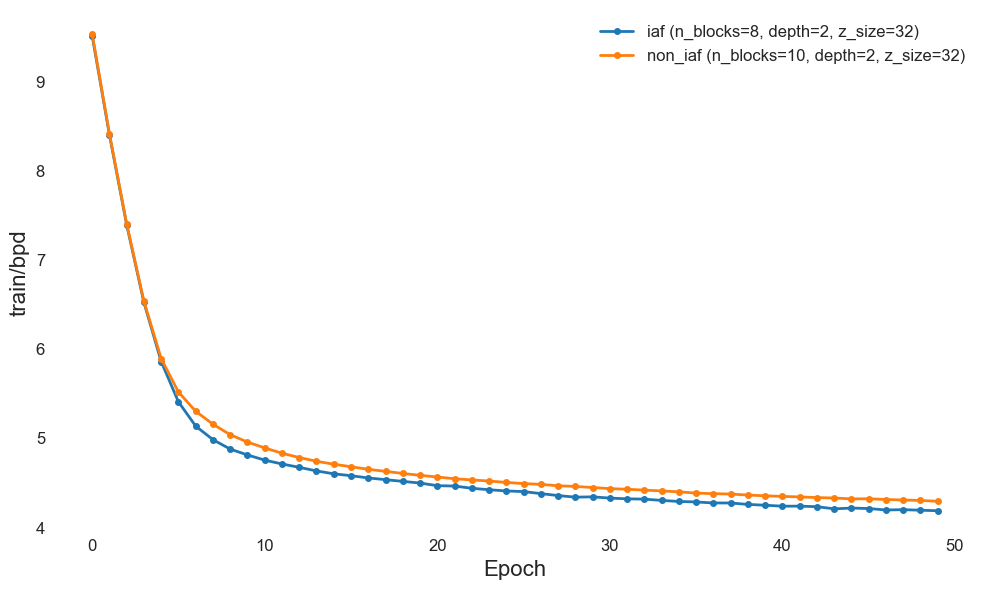

Saved: log_plots/capacity/more_blocks/train_elbo_over_training.png


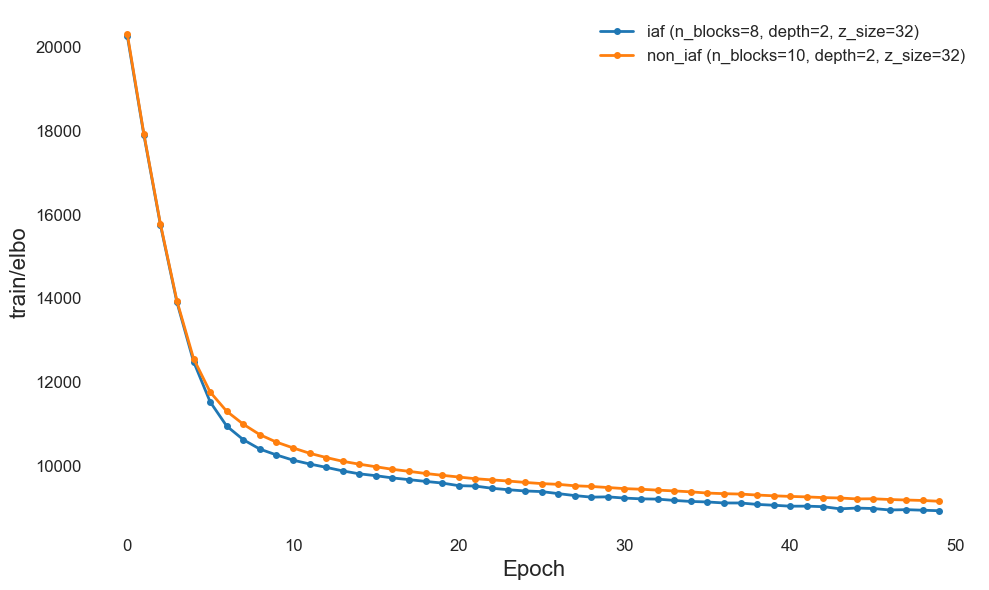

Saved: log_plots/capacity/more_blocks/train_kl_over_training.png


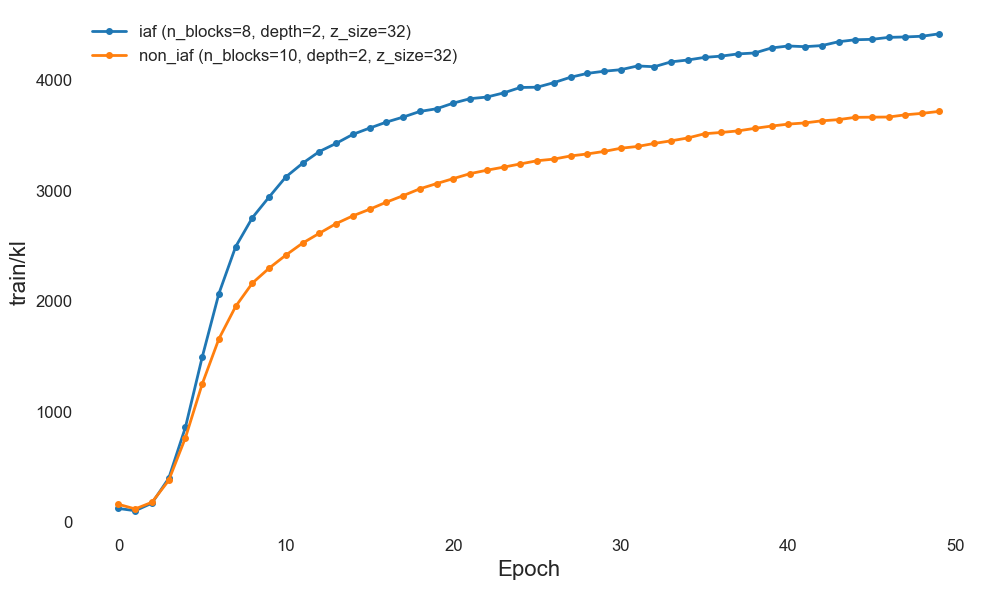

Saved: log_plots/capacity/more_blocks/train_kl_obj_over_training.png


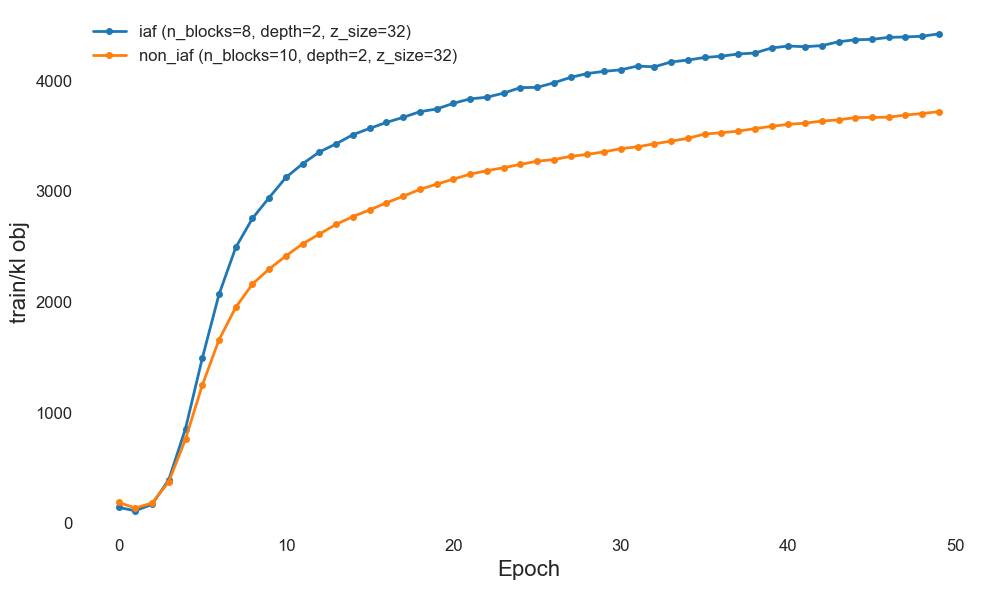

Saved: log_plots/capacity/more_blocks/train_log_p_x_z_over_training.png


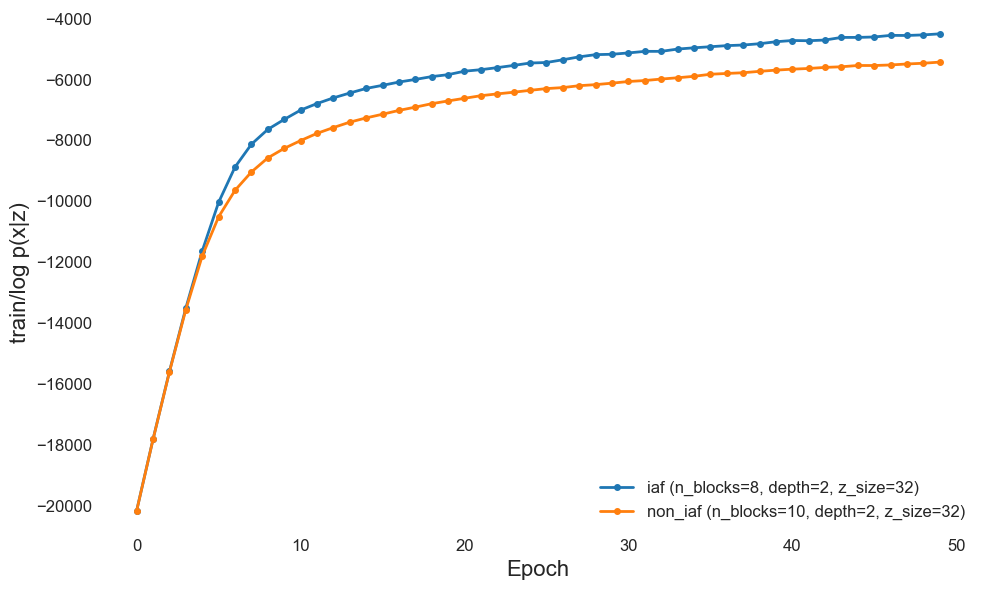

In [17]:
# Specify your log file paths here
# You can add multiple files to compare different runs
log_files = [
    "logs/capacity/more_blocks/iaf.txt",
    "logs/capacity/more_blocks/non_iaf.txt",
]

parsed_logs = []
for log_file in log_files:
    try:
        parsed = parse_log_file(log_file)
        parsed_logs.append(parsed)
        print(f"✓ Parsed {log_file}")
        print(f"  Found {len(parsed['metrics'])} metrics")
        print(f"  Config: {parsed['config']}")
    except Exception as e:
        print(f"✗ Error parsing {log_file}: {e}")

print(f"\nTotal logs parsed: {len(parsed_logs)}")


# Plot all metrics
if parsed_logs:
    plot_metrics(parsed_logs, save_dir="log_plots/capacity/more_blocks")
else:
    print("No logs to plot. Please specify log files in the cell above.")